In [1]:
#  Install Libraries and Download Data
import os
import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Install required tools for processing compressed files
os.system('pip install patool pyunpack')

print("Starting dataset download...")

# Download MobiFall Dataset v2.0
path = kagglehub.dataset_download("kmknation/mobifall-dataset-v20")

print("Dataset path established at:")
print(path)

# Verify if files exist or extraction is needed
files_in_path = os.listdir(path)
print("Files found in download folder:")
print(files_in_path)

Starting dataset download...


100%|██████████| 90.2M/90.2M [00:01<00:00, 85.1MB/s]

Extracting files...


Dataset path established at:
/root/.cache/kagglehub/datasets/kmknation/mobifall-dataset-v20/versions/1
Files found in download folder:
['MobiFall_Dataset_v2.0']


In [2]:
# Data Loader and Windowing Function

def load_mobifall_manual_parse(base_path):
    # Locate the inner folder
    target_folder = 'MobiFall_Dataset_v2.0'
    dataset_root = None

    # Search for the dataset folder
    for root, dirs, files in os.walk(base_path):
        if target_folder in dirs:
            dataset_root = os.path.join(root, target_folder)
            break

    if not dataset_root:
        # Fallback: if not found inside, maybe the base_path is the root
        dataset_root = base_path

    print(f"Scanning directory: {dataset_root}")

    data_frames = []
    # Codes strictly from MobiFall documentation
    fall_codes = ['FOL', 'FKL', 'BSC', 'SDL']
    adl_codes = ['STD', 'WAL', 'JOG', 'JUM', 'STU', 'STN', 'SCH', 'CSI', 'CSO']

    files_processed = 0

    for root, dirs, files in os.walk(dataset_root):
        for file in files:
            # We look for Accelerometer files first
            if file.endswith(".txt") and "_acc_" in file:
                try:
                    parts = file.replace('.txt', '').split('_')
                    if len(parts) < 4: continue

                    code = parts[0]

                    # Assign Label (1 for Fall, 0 for Normal)
                    if code in fall_codes: label = 1
                    elif code in adl_codes: label = 0
                    else: continue

                    # Find matching Gyroscope file
                    gyro_file = file.replace('_acc_', '_gyro_')
                    acc_path = os.path.join(root, file)
                    gyro_path = os.path.join(root, gyro_file)

                    # If gyro file missing, skip this sequence
                    if not os.path.exists(gyro_path): continue

                    # Function to parse the messy text format
                    def parse_txt_file(filepath):
                        valid_data = []
                        with open(filepath, 'r') as f:
                            for line in f:
                                line = line.strip()
                                # Skip comments (#) or empty lines
                                if not line or line.startswith('#') or line.startswith('@'):
                                    continue
                                # Ensure line starts with number or minus
                                if not (line[0].isdigit() or line.startswith('-')):
                                    continue

                                # Convert text line to numbers
                                parts = line.replace(',', ' ').split()
                                try:
                                    nums = [float(p) for p in parts]
                                    if len(nums) >= 3:
                                        valid_data.append(nums[-3:]) # Keep last 3 columns (X, Y, Z)
                                except ValueError:
                                    continue
                        return np.array(valid_data)

                    # Extract data
                    acc_val = parse_txt_file(acc_path)
                    gyro_val = parse_txt_file(gyro_path)

                    # Ensure we have enough data
                    if len(acc_val) < 10 or len(gyro_val) < 10: continue

                    # Trim arrays to the same length (Acc and Gyro must match)
                    min_len = min(len(acc_val), len(gyro_val))
                    acc_val = acc_val[:min_len]
                    gyro_val = gyro_val[:min_len]

                    # Combine into 6-axis data
                    combined_data = np.hstack((acc_val, gyro_val))

                    data_frames.append({
                        "data": combined_data,
                        "label": label
                    })

                    files_processed += 1
                    if files_processed % 100 == 0:
                        print(f"Processed {files_processed} sequences...")

                except Exception as e:
                    continue

    print(f"Total sequences loaded: {len(data_frames)}")
    return data_frames

def create_windows(raw_data_list, window_size=128, step=64):
    X = []
    y = []

    print("Starting data segmentation (Windowing)...")

    for item in raw_data_list:
        data = item['data']
        label = item['label']

        # Create sliding windows
        for i in range(0, len(data) - window_size, step):
            window = data[i : i + window_size]

            # Keep only full windows
            if len(window) == window_size:
                X.append(window)
                y.append(label)

    return np.array(X), np.array(y)

# --- EXECUTE LOADING ---
raw_data = load_mobifall_manual_parse(path)
X, y = create_windows(raw_data)

print("Data Shapes:")
print(X.shape)
print(y.shape)

Scanning directory: /root/.cache/kagglehub/datasets/kmknation/mobifall-dataset-v20/versions/1/MobiFall_Dataset_v2.0
Processed 100 sequences...
Processed 200 sequences...
Processed 300 sequences...
Processed 400 sequences...
Processed 500 sequences...
Processed 600 sequences...
Total sequences loaded: 630
Starting data segmentation (Windowing)...
Data Shapes:
(15366, 128, 6)
(15366,)


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import pandas as pd
import time
import os

# 1. Split Data (Standard 80-20 Split)
# X aur y pichle step se aa rahe hain
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

# --- MODEL ARCHITECTURES ---
INPUT_SHAPE = (128, 6)

# 1. CNN (Baseline - Best for Edge)
def build_cnn_model():
    model = models.Sequential([
        layers.Conv1D(64, 3, activation='relu', input_shape=INPUT_SHAPE),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.Conv1D(32, 3, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. LSTM (Good for Sequences)
def build_lstm_model():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 3. CNN-LSTM (Hybrid - High Accuracy)
def build_cnn_lstm_model():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        # CNN Part
        layers.Conv1D(64, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        # LSTM Part
        layers.LSTM(64),
        layers.Dropout(0.3),
        # Decision
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 4. Transformer (Advanced)
def build_transformer_model():
    inputs = layers.Input(shape=INPUT_SHAPE)
    # Attention Block
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=4)(inputs, inputs)
    x = layers.Add()([inputs, attention])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    # Feed Forward
    x_ff = layers.Conv1D(64, 1, activation='relu')(x)
    x_ff = layers.Conv1D(6, 1)(x_ff)
    x = layers.Add()([x, x_ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    # Output
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print("All Model Architectures Defined.")

Training Data: (12292, 128, 6)
Testing Data: (3074, 128, 6)
All Model Architectures Defined.


In [9]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Configuration
models_to_test = [
    ("1D-CNN", build_cnn_model),
    ("LSTM", build_lstm_model),
    ("CNN-LSTM", build_cnn_lstm_model),
    ("Transformer", build_transformer_model)
]

results = []
model_predictions = {} # To store predictions for visualization
best_model = None # To store the CNN model for saving later

print(f"Starting Comparison on {len(X_train)} samples...")

for name, build_fn in models_to_test:
    print(f"\n--- Processing {name} ---")
    start_time = time.time()

    # 1. Build & Train
    model = build_fn()

    # Training for 10 epochs
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_test, y_test),
        verbose=1
    )

    training_time = time.time() - start_time

    # 2. Evaluate
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    params = model.count_params()

    print(f"{name} Accuracy: {accuracy:.4f}")

    # 3. Store Predictions for Confusion Matrix
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    model_predictions[name] = y_pred

    # 4. Store Results for Table
    results.append({
        "Model": name,
        "Accuracy": accuracy * 100,
        "Loss": loss,
        "Parameters": params,
        "Training Time": training_time
    })

    # Keep track of the best model (We prioritize CNN for Edge)
    if name == "1D-CNN":
        best_model = model

# --- DISPLAY COMPARISON TABLE ---
comparison_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\nFINAL MODEL COMPARISON TABLE")
print(comparison_df.to_string(index=False))

Starting Comparison on 12292 samples...

--- Processing 1D-CNN ---
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9250 - loss: 0.2070 - val_accuracy: 0.9499 - val_loss: 0.1885
Epoch 2/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9500 - loss: 0.1370 - val_accuracy: 0.9473 - val_loss: 0.1707
Epoch 3/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9513 - loss: 0.1237 - val_accuracy: 0.9408 - val_loss: 0.2128
Epoch 4/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9594 - loss: 0.1076 - val_accuracy: 0.9577 - val_loss: 0.1765
Epoch 5/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9597 - loss: 0.1046 - val_accuracy: 0.9466 - val_loss: 0.1964
Epoch 6/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9632 - loss: 0.0966 - val_accuracy: 0.9593 - val_loss: 0.1682
Epoch 7/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9652 - loss: 0.0936 - val_accuracy: 0.9561 - val_loss: 0.1554
Epoch 8/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9680 - loss: 0.0831 - val_accuracy: 0.95

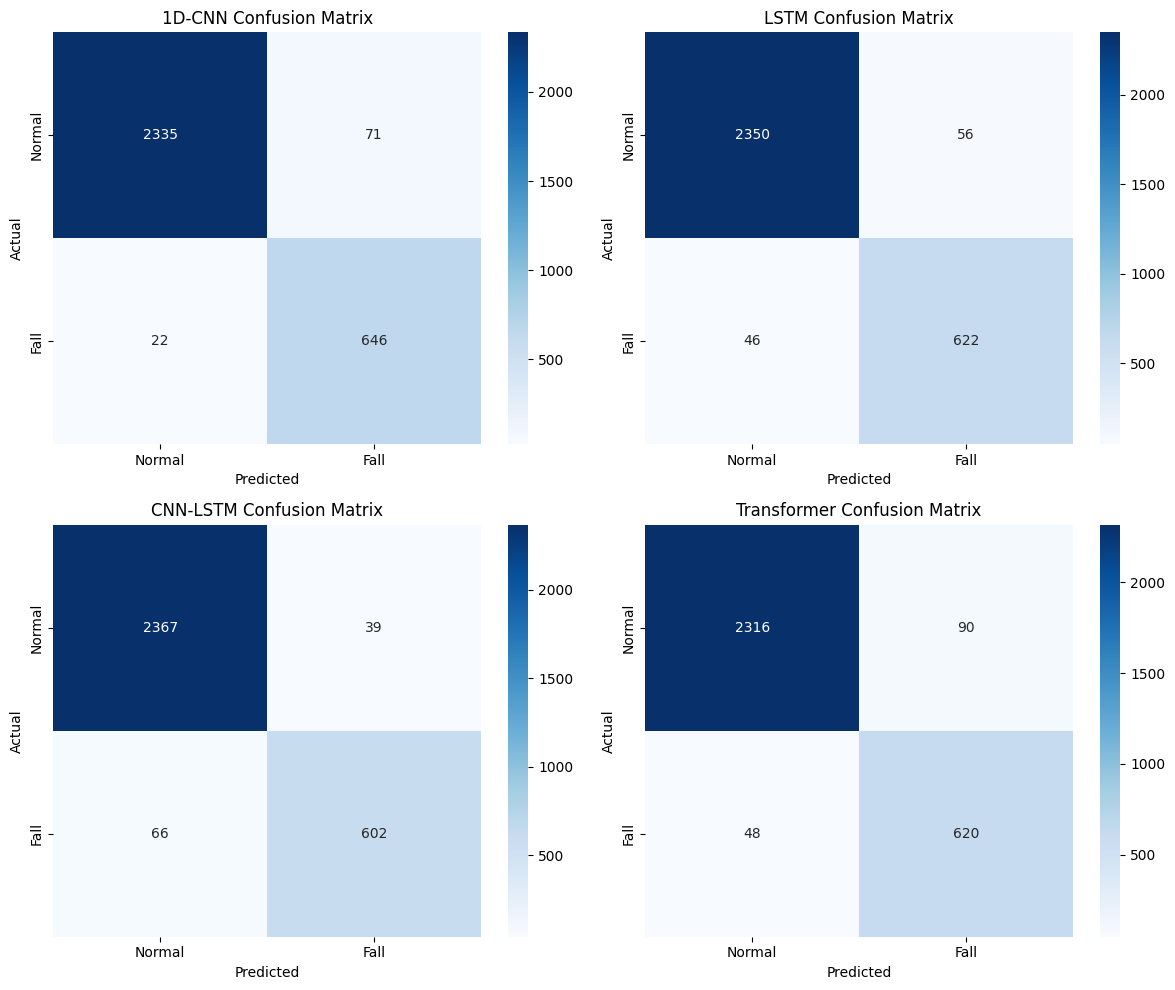

/tmp/ipython-input-283044481.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')


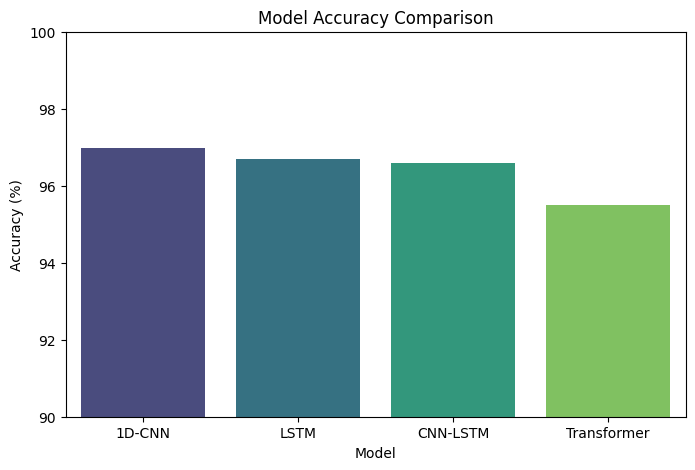


--- Detailed Classification Report for 1D-CNN (Selected Model) ---
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      2406
        Fall       0.90      0.97      0.93       668

    accuracy                           0.97      3074
   macro avg       0.95      0.97      0.96      3074
weighted avg       0.97      0.97      0.97      3074



In [10]:
# Set up the figure for 2x2 Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot Confusion Matrix for each model
for i, (name, y_pred) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fall'],
                yticklabels=['Normal', 'Fall'])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# --- BAR CHART FOR ACCURACY COMPARISON ---
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.ylim(90, 100) # Zoom in to see differences
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

# --- PRINT DETAILED REPORT FOR BEST MODEL ---
print("\n--- Detailed Classification Report for 1D-CNN (Selected Model) ---")
print(classification_report(y_test, model_predictions['1D-CNN'], target_names=['Normal', 'Fall']))

In [11]:
# Save the CNN Model (Standard Format)
if best_model:
    best_model.save('mobifall_model.h5')
    print("\nSaved Baseline CNN as 'mobifall_model.h5'")

    # Convert to TFLite (Optimized for Raspberry Pi)
    converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT] # Quantization ON
    tflite_model = converter.convert()

    with open('mobifall_edge_model.tflite', 'wb') as f:
        f.write(tflite_model)

    print("Converted to 'mobifall_edge_model.tflite' (Quantized)")

    # Size Comparison check
    size_h5 = os.path.getsize('mobifall_model.h5') / 1024
    size_tflite = os.path.getsize('mobifall_edge_model.tflite') / 1024
    print(f"Size Reduction: {size_h5:.2f}KB -> {size_tflite:.2f}KB")
else:
    print("Error: CNN Model not found in training loop.")


Saved Baseline CNN as 'mobifall_model.h5'
Saved artifact at '/tmp/tmpdtp84mox'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_74')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134574550012880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134574550013840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134574550011344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134574550014224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134574550010384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134574550010000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134574550012112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134574550012304: TensorSpec(shape=(), dtype=tf.resource, name=None)
Converted to 'mobifall_edge_model.tflite' (Quantized)
Size Reduction: 137.68KB -> 15.05KB


In [ ]:
from google.colab import files

# Download Standard Keras Model (.h5)
try:
    print("Downloading mobifall_model.h5...")
    files.download('mobifall_model.h5')
except Exception as e:
    print(f"Error downloading H5 model: {e}")

# Download Edge/Raspberry Pi Model (.tflite)
try:
    print("Downloading mobifall_edge_model.tflite...")
    files.download('mobifall_edge_model.tflite')
except Exception as e:
    print(f"Error downloading TFLite model: {e}")